<a href="https://colab.research.google.com/github/priyanshugupta-26/Guassain_noice-and-Averaging_filter-/blob/main/cv_gaussian_noice_and_averaging_filter_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

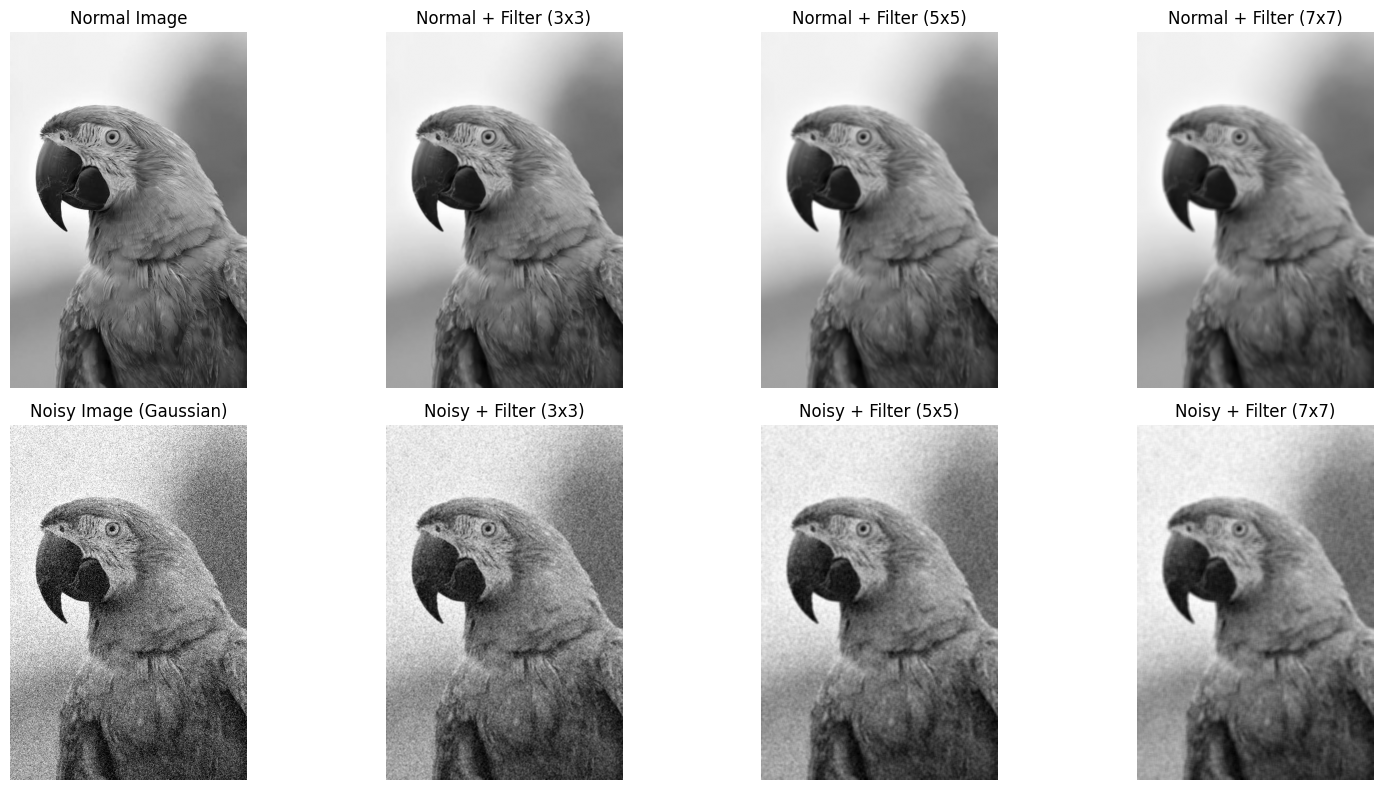

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Normal image import karein ('parrot.jpeg') grayscale mode mein
img = cv2.imread('parrot.jpeg', 0)

if img is None:
    print("Error: 'parrot.jpeg' image nahi mili! Kripya check karein file path sahi hai ya nahi.")
else:
    # 2. Additive Gaussian Noise generate karein
    mean = 0
    stdev = 40  # Noise intensity
    gaussian_noise = np.random.normal(mean, stdev, img.shape)

    # Additive rule: Normal image + Gaussian Noise
    noisy_img = img + gaussian_noise
    # Values ko 0-255 range me clip karke uint8 me convert karein
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    # 3. Averaging Filter ke kernels define karein (3x3, 5x5, 7x7)
    kernel_3x3 = np.ones((3, 3), np.float32) / 9
    kernel_5x5 = np.ones((5, 5), np.float32) / 25
    kernel_7x7 = np.ones((7, 7), np.float32) / 49

    # 4. Normal image par Averaging Filter apply karein
    clean_blur_3x3 = cv2.filter2D(img, -1, kernel_3x3)
    clean_blur_5x5 = cv2.filter2D(img, -1, kernel_5x5)
    clean_blur_7x7 = cv2.filter2D(img, -1, kernel_7x7)

    # 5. Noisy image par Averaging Filter apply karein
    noisy_blur_3x3 = cv2.filter2D(noisy_img, -1, kernel_3x3)
    noisy_blur_5x5 = cv2.filter2D(noisy_img, -1, kernel_5x5)
    noisy_blur_7x7 = cv2.filter2D(noisy_img, -1, kernel_7x7)

    # 6. Saare images ko ek sath plot karein
    plt.figure(figsize=(16, 8))

    # --- Row 1: Normal Image & Normal Image with Filters ---
    plt.subplot(2, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Normal Image")
    plt.axis('off')

    plt.subplot(2, 4, 2)
    plt.imshow(clean_blur_3x3, cmap='gray')
    plt.title("Normal + Filter (3x3)")
    plt.axis('off')

    plt.subplot(2, 4, 3)
    plt.imshow(clean_blur_5x5, cmap='gray')
    plt.title("Normal + Filter (5x5)")
    plt.axis('off')

    plt.subplot(2, 4, 4)
    plt.imshow(clean_blur_7x7, cmap='gray')
    plt.title("Normal + Filter (7x7)")
    plt.axis('off')

    # --- Row 2: Noisy Image & Noisy Image with Filters ---
    plt.subplot(2, 4, 5)
    plt.imshow(noisy_img, cmap='gray')
    plt.title("Noisy Image (Gaussian)")
    plt.axis('off')

    plt.subplot(2, 4, 6)
    plt.imshow(noisy_blur_3x3, cmap='gray')
    plt.title("Noisy + Filter (3x3)")
    plt.axis('off')

    plt.subplot(2, 4, 7)
    plt.imshow(noisy_blur_5x5, cmap='gray')
    plt.title("Noisy + Filter (5x5)")
    plt.axis('off')

    plt.subplot(2, 4, 8)
    plt.imshow(noisy_blur_7x7, cmap='gray')
    plt.title("Noisy + Filter (7x7)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()